# Condensate free-field cross-check (Eqs. 1.23 PS, 1.55 FS)
Stochastic (`jj_corr_dilute`, free $U=1$, `h0/condensate/*`, jackknife over hits) vs the DENSE exact
reference (`condensate_deter_free`, complete unit-source basis).  Three bilinears `etadag_xi`,
`xidag_eta`, `xidag_1mDdag_eta` (area-weighted spacetime-summed traces); then
$\sigma_{PS}=$`etadag_xi`$+$`xidag_eta`, $\sigma_{FS}=$`etadag_xi`$-$`xidag_1mDdag_eta`; spacetime-average
by $/V_{st}$, $V_{st}=N_t\sum_n A_n$.  Run `tmp_condensate_deter_claude.sh` first.

In [1]:
import numpy as np
import h5py
import glob
import matplotlib.pyplot as plt

ESN   = 'data_free_vmRe0.000000vmIm0.000000/'
DENSE = ESN + 'condensate_deter_L1/cond.h5'
STOCH = ESN + 'corr_dil_nt02_nhits4_s1td2/'    # free stochastic run -- match tmp_condensate_deter NHITS (set to your dir)
KEYS  = ['etadag_xi', 'xidag_eta', 'xidag_1mDdag_eta']

In [2]:
# ----- dense exact reference -----
with h5py.File(DENSE, 'r') as f:
    Vst = f['Vst'][()][0]
    dense = {k: f['condensate/'+k+'/real'][()][0] + 1j*f['condensate/'+k+'/imag'][()][0] for k in KEYS}
dense['sigma_PS'] = dense['etadag_xi'] + dense['xidag_eta']
dense['sigma_FS'] = dense['etadag_xi'] - dense['xidag_1mDdag_eta']
print('Vst =', Vst)
for k in KEYS + ['sigma_PS', 'sigma_FS']:
    print('%-18s dense avg = % .6e %+.6ej' % (k, (dense[k]/Vst).real, (dense[k]/Vst).imag))

Vst = 1608.4954386379736
etadag_xi          dense avg = -1.000000e+00 -4.679822e-18j
xidag_eta          dense avg = -1.000000e+00 +4.679822e-18j
xidag_1mDdag_eta   dense avg =  9.999369e-01 +3.016323e-17j
sigma_PS           dense avg = -2.000000e+00 +0.000000e+00j
sigma_FS           dense avg = -1.999937e+00 -3.484305e-17j


In [3]:
# ----- stochastic per-hit (complete-gated), jackknife over hits -----
def stoch_hits(key):
    out = []
    for fn in sorted(glob.glob(STOCH + 'corr.0.h*.h5')):
        with h5py.File(fn, 'r') as h:
            if 'complete' not in h:
                continue
            kk = 'h0/condensate/' + key
            out.append(h[kk + '/real'][()][0] + 1j*h[kk + '/imag'][()][0])
    return np.array(out)

def jk_complex(a):                 # (mean, err_re, err_im) over hits
    H = len(a)
    s = a.sum()
    samp = np.array([(s - a[i])/(H - 1) for i in range(H)])
    est = samp.mean()
    vre = (H - 1)*np.mean((samp.real - est.real)**2)
    vim = (H - 1)*np.mean((samp.imag - est.imag)**2)
    return est, np.sqrt(vre), np.sqrt(vim)

raw = {k: stoch_hits(k) for k in KEYS}
nh = len(raw['etadag_xi'])
assert nh > 0, 'no complete hits in %s -- check the dir name (nhits/td) and that the run finished' % STOCH
raw['sigma_PS'] = raw['etadag_xi'] + raw['xidag_eta']
raw['sigma_FS'] = raw['etadag_xi'] - raw['xidag_1mDdag_eta']
print('stochastic complete hits:', nh)

stochastic complete hits: 4


In [4]:
# ----- comparison table: stoch (avg /Vst) +- jk err  vs  dense exact ; pull = (stoch-dense)/err -----
print('%-18s %26s %26s %12s' % ('quantity', 'stoch /Vst (re,im)', 'dense /Vst (re,im)', 'pull(re,im)'))
for k in KEYS + ['sigma_PS', 'sigma_FS']:
    est, ere, eim = jk_complex(raw[k])
    est, ere, eim = est/Vst, ere/Vst, eim/Vst
    d = dense[k]/Vst
    pr = (est.real - d.real)/ere if ere > 0 else 0.0
    pi = (est.imag - d.imag)/eim if eim > 0 else 0.0
    print('%-18s % .4e%+.4ej(+-%.1e,%.1e) % .4e%+.4ej   %+.2f,%+.2f' %
          (k, est.real, est.imag, ere, eim, d.real, d.imag, pr, pi))

quantity                   stoch /Vst (re,im)         dense /Vst (re,im)  pull(re,im)
etadag_xi          -1.0000e+00-1.1992e-03j(+-5.2e-12,4.6e-04) -1.0000e+00-4.6798e-18j   +10.90,-2.60
xidag_eta          -1.0000e+00+1.1992e-03j(+-5.2e-12,4.6e-04) -1.0000e+00+4.6798e-18j   +10.90,+2.60
xidag_1mDdag_eta    9.9994e-01+1.1992e-03j(+-4.6e-06,4.6e-04)  9.9994e-01+3.0163e-17j   +0.08,+2.60
sigma_PS           -2.0000e+00+0.0000e+00j(+-1.0e-11,0.0e+00) -2.0000e+00+0.0000e+00j   +10.90,+0.00
sigma_FS           -1.9999e+00-2.3983e-03j(+-4.6e-06,9.2e-04) -1.9999e+00-3.4843e-17j   -0.08,-2.60


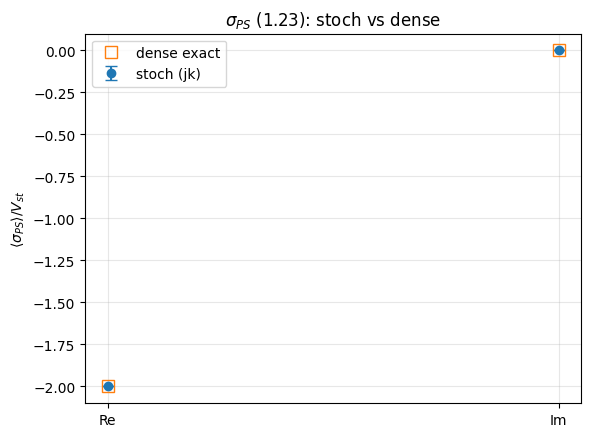

In [5]:
# sigma_PS: stoch (errorbar, Re & Im) vs dense exact (lines).  /Vst.
est, ere, eim = jk_complex(raw['sigma_PS'])
d = dense['sigma_PS']/Vst
plt.figure()
plt.errorbar([0, 1], [est.real/Vst, est.imag/Vst], yerr=[ere/Vst, eim/Vst], fmt='o', capsize=4, label='stoch (jk)')
plt.plot([0, 1], [d.real, d.imag], 's', ms=9, mfc='none', label='dense exact')
plt.xticks([0, 1], ['Re', 'Im'])
plt.ylabel(r'$\langle\sigma_{PS}\rangle / V_{st}$'); plt.title(r'$\sigma_{PS}$ (1.23): stoch vs dense')
plt.legend(); plt.grid(alpha=0.3)

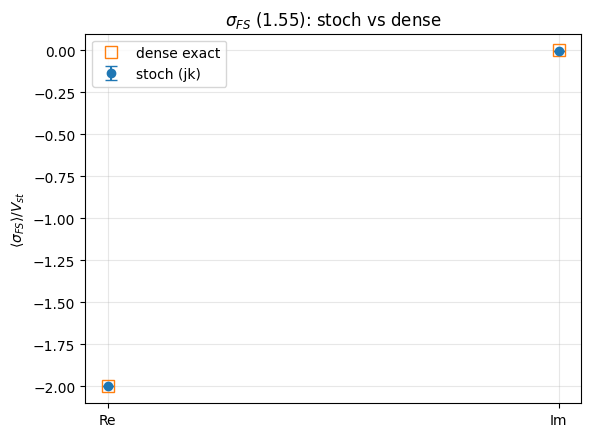

In [6]:
# sigma_FS: stoch (errorbar, Re & Im) vs dense exact (lines).  /Vst.
est, ere, eim = jk_complex(raw['sigma_FS'])
d = dense['sigma_FS']/Vst
plt.figure()
plt.errorbar([0, 1], [est.real/Vst, est.imag/Vst], yerr=[ere/Vst, eim/Vst], fmt='o', capsize=4, label='stoch (jk)')
plt.plot([0, 1], [d.real, d.imag], 's', ms=9, mfc='none', label='dense exact')
plt.xticks([0, 1], ['Re', 'Im'])
plt.ylabel(r'$\langle\sigma_{FS}\rangle / V_{st}$'); plt.title(r'$\sigma_{FS}$ (1.55): stoch vs dense')
plt.legend(); plt.grid(alpha=0.3)